# GT-Supervised Auxiliary Path를 Deformable DETR에 이식하는 검증 실험

이 노트북은 `SenseTime/deformable-detr`의 **one-stage / 4-scale / no iterative refinement** 구조를 사용한다.

연구 질문은 auxiliary branch 자체가 빠르게 box를 회귀하는지가 아니라 다음과 같다.

> 학습할 때만 GT 중심이 포함된 encoder patch를 선택해 기존 bbox predictor를 직접 감독하면, GT를 전혀 사용하지 않는 main DETR 추론 경로의 수렴과 AP가 개선되는가?

핵심 제약:

- GT box는 patch **선택**과 auxiliary target에만 사용한다.
- auxiliary 입력에는 GT의 연속 중심 좌표, width, height, class embedding을 넣지 않는다.
- auxiliary reference는 GT 중심이 아니라 선택된 patch의 중심이다.
- main/auxiliary는 같은 bbox predictor parameter와 같은 reference-point decoding을 사용한다.
- validation과 inference에서는 auxiliary path를 실행하지 않는다.
- 같은 patch에 여러 GT 중심이 들어가면 모순된 target이 되므로 그 collision group은 auxiliary loss에서 제외하고 coverage를 기록한다.


## 0. 실행 순서와 주의사항

1. 기본값은 `RUN_MODE='smoke'`이며 기존 데이터의 300/100 split으로 3 epoch를 학습한다.
2. 최종 실험은 설정 셀에서 `RUN_MODE='full'`로 바꾸면 3,000/750장, 10 epoch를 사용한다.
3. full 실험은 GPU를 권장한다. Windows에서는 호환성을 위해 pure PyTorch deformable attention을 기본 사용하므로 Linux/Colab의 CUDA kernel보다 느릴 수 있다.
4. 공식 지표는 항상 GT 없는 main detector 출력으로만 계산한다. Auxiliary IoU는 학습 진단값일 뿐 최종 성능이 아니다.
5. 첫 실행에는 Hugging Face pretrained checkpoint를 다운로드한다. VOC 이미지와 XML은 기존 `data/VOCdevkit/VOC2007`을 재사용한다.


In [1]:
# 필요한 패키지가 없을 때만 현재 Jupyter kernel에 설치합니다.
import importlib.util
import subprocess
import sys

requirements = {
    'transformers': 'transformers==5.14.0',
    'timm': 'timm>=1.0.28',
    'scipy': 'scipy>=1.18.0',
    'torchmetrics': 'torchmetrics>=1.9.0',
    'pycocotools': 'pycocotools>=2.0.11',
}
missing = [package for module, package in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('설치가 끝났습니다. Kernel을 재시작한 뒤 이 셀부터 다시 실행하세요.')
else:
    print('Required packages are already installed.')


Required packages are already installed.


In [2]:
import copy
import gc
import hashlib
import json
import math
import os
import platform
import random
import time
import warnings
import xml.etree.ElementTree as ET
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm
from transformers import (
    AutoConfig,
    AutoImageProcessor,
    DeformableDetrForObjectDetection,
)

print('Python:', platform.python_version())
print('PyTorch:', torch.__version__)
print('Transformers:', transformers.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


c:\Users\이노뎁\Desktop\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.14.7
PyTorch: 2.11.0+cu128
Transformers: 5.14.0
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


## 1. 실험 설정

`full`은 기존 노트북과 같은 deterministic split을 재현한다. 전체 ablation 7개 × 10 epoch는 오래 걸리므로 필요하면 먼저 smoke mode를 실행한다.


In [3]:
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
VOC_ROOT = DATA_DIR / 'VOCdevkit' / 'VOC2007'
OUTPUT_DIR = ROOT / 'outputs' / 'detr_gt_auxiliary'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT = 'SenseTime/deformable-detr'
RUN_MODE = 'smoke'          # 300/100장, 3 epoch
RUN_EXPERIMENTS = True
SAVE_LAST_CHECKPOINT = False

SEED = 42
FULL_TRAIN_IMAGES = 3000
FULL_VAL_IMAGES = 750
SMOKE_TRAIN_IMAGES = 300
SMOKE_VAL_IMAGES = 100

if RUN_MODE == 'smoke':
    TRAIN_IMAGES, VAL_IMAGES, EPOCHS = SMOKE_TRAIN_IMAGES, SMOKE_VAL_IMAGES, 3
    IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 384, 640
    EXPERIMENTS = ['baseline', 'shared_detach', 'shared_e2e']
    SEEDS = [SEED]
elif RUN_MODE == 'full':
    TRAIN_IMAGES, VAL_IMAGES, EPOCHS = FULL_TRAIN_IMAGES, FULL_VAL_IMAGES, 10
    IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 640, 1000
    EXPERIMENTS = [
        'baseline', 'separate', 'shared_detach', 'shared_e2e',
        'random_patch', 'no_adapter', 'shared_decay',
    ]
    SEEDS = [SEED]  # 1차 결과 후 [42, 43, 44]로 확장
else:
    raise ValueError("RUN_MODE must be 'smoke' or 'full'")

BATCH_SIZE = 2 if torch.cuda.is_available() else 1
NUM_WORKERS = 0  # Windows/Jupyter 안정성
LR = 2e-4
BACKBONE_LR = 2e-5
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 0.1
BASE_AUX_WEIGHT = 0.5
FEATURE_LEVEL = 0       # 가장 높은 해상도의 encoder level
HORIZONTAL_FLIP_P = 0.5
USE_AMP = torch.cuda.is_available()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DISABLE_CUSTOM_KERNELS = (os.name == 'nt') or not torch.cuda.is_available()

VOC_CLASSES = (
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',
    'dog', 'horse', 'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor',
)
LABEL2ID = {name: index for index, name in enumerate(VOC_CLASSES)}
ID2LABEL = {index: name for name, index in LABEL2ID.items()}

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print({
    'run_mode': RUN_MODE, 'train_images': TRAIN_IMAGES,
    'val_images': VAL_IMAGES, 'epochs': EPOCHS,
    'batch_size': BATCH_SIZE, 'device': str(DEVICE),
    'disable_custom_kernels': DISABLE_CUSTOM_KERNELS,
    'experiments': EXPERIMENTS,
})


{'run_mode': 'full', 'train_images': 3000, 'val_images': 750, 'epochs': 10, 'batch_size': 2, 'device': 'cuda', 'disable_custom_kernels': True, 'experiments': ['baseline', 'separate', 'shared_detach', 'shared_e2e', 'random_patch', 'no_adapter', 'shared_decay']}


## 2. 기존 Pascal VOC 2007 데이터와 동일 split 재현

기존 `gt_supervised_refinement_validation.ipynb`와 동일하게 trainval 5,011장 중 seed 42로 3,750장을 선택하고, seed 43으로 3,000/750을 나눈다. 생성된 manifest는 결과 폴더에 저장된다.


In [4]:
assert (VOC_ROOT / 'JPEGImages').exists(), (
    f'{VOC_ROOT}를 찾을 수 없습니다. 기존 데이터 셀을 먼저 실행하세요.'
)
assert (VOC_ROOT / 'Annotations').exists()
trainval_file = VOC_ROOT / 'ImageSets' / 'Main' / 'trainval.txt'
all_ids = [line.strip() for line in trainval_file.read_text().splitlines() if line.strip()]
assert len(all_ids) == 5011, f'Expected 5011 VOC trainval images, got {len(all_ids)}'

def parse_voc_record(image_id):
    annotation_path = VOC_ROOT / 'Annotations' / f'{image_id}.xml'
    root = ET.parse(annotation_path).getroot()
    width = int(root.findtext('size/width'))
    height = int(root.findtext('size/height'))
    boxes, labels = [], []
    for obj in root.findall('object'):
        name = obj.findtext('name')
        if name not in LABEL2ID:
            continue
        box = obj.find('bndbox')
        x1 = max(0.0, float(box.findtext('xmin')) - 1.0)
        y1 = max(0.0, float(box.findtext('ymin')) - 1.0)
        x2 = min(float(width), float(box.findtext('xmax')))
        y2 = min(float(height), float(box.findtext('ymax')))
        if x2 > x1 and y2 > y1:
            boxes.append([x1, y1, x2, y2])
            labels.append(LABEL2ID[name])
    return {
        'image_id': image_id,
        'image_path': str(VOC_ROOT / 'JPEGImages' / f'{image_id}.jpg'),
        'width': width,
        'height': height,
        'boxes_xyxy': boxes,
        'labels': labels,
    }

selection_rng = np.random.default_rng(SEED)
selected_ids = selection_rng.permutation(all_ids)[:FULL_TRAIN_IMAGES + FULL_VAL_IMAGES]
records = [parse_voc_record(str(image_id)) for image_id in tqdm(selected_ids, desc='VOC XML')]
records = [record for record in records if record['boxes_xyxy']]
assert len(records) == FULL_TRAIN_IMAGES + FULL_VAL_IMAGES

split_rng = np.random.default_rng(SEED + 1)
order = split_rng.permutation(len(records))
full_train_records = [records[index] for index in order[:FULL_TRAIN_IMAGES]]
full_val_records = [records[index] for index in order[FULL_TRAIN_IMAGES:FULL_TRAIN_IMAGES + FULL_VAL_IMAGES]]

# 기존 노트북 실행 결과와 동일한지 확인한다.
train_object_count = sum(len(record['boxes_xyxy']) for record in full_train_records)
val_object_count = sum(len(record['boxes_xyxy']) for record in full_val_records)
assert (train_object_count, val_object_count) == (9180, 2530), (
    '기존 split과 다릅니다:', train_object_count, val_object_count
)

train_records = full_train_records[:TRAIN_IMAGES]
val_records = full_val_records[:VAL_IMAGES]
manifest = {
    'seed': SEED,
    'selection_seed': SEED,
    'split_seed': SEED + 1,
    'full_train_ids': [record['image_id'] for record in full_train_records],
    'full_val_ids': [record['image_id'] for record in full_val_records],
}
(OUTPUT_DIR / 'voc2007_split_manifest.json').write_text(
    json.dumps(manifest, indent=2), encoding='utf-8'
)
print(f'Full split: train={len(full_train_records)} ({train_object_count} objects), '
      f'val={len(full_val_records)} ({val_object_count} objects)')
print(f'Current run: train={len(train_records)}, val={len(val_records)}')


VOC XML: 100%|██████████| 3750/3750 [00:01<00:00, 2864.87it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=3000, val=750


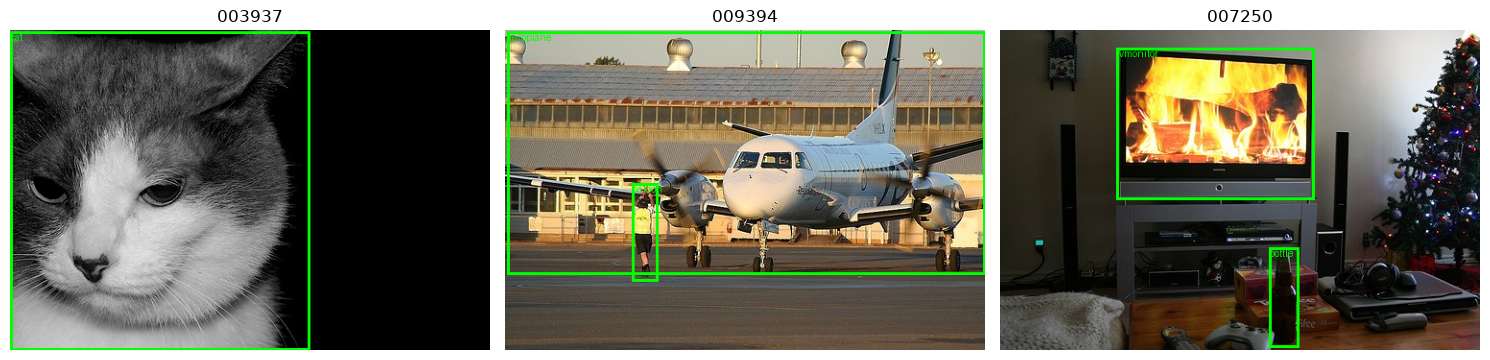

In [5]:
def show_dataset_examples(items, count=3):
    count = min(count, len(items))
    fig, axes = plt.subplots(1, count, figsize=(5 * count, 5))
    axes = np.atleast_1d(axes)
    for axis, record in zip(axes, items[:count]):
        image = Image.open(record['image_path']).convert('RGB')
        draw = ImageDraw.Draw(image)
        for box, label in zip(record['boxes_xyxy'], record['labels']):
            draw.rectangle(box, outline='lime', width=3)
            draw.text((box[0], box[1]), ID2LABEL[label], fill='lime')
        axis.imshow(image)
        axis.set_title(record['image_id'])
        axis.axis('off')
    plt.tight_layout()

show_dataset_examples(train_records)


## 3. 데이터셋과 Hugging Face processor

Processor가 VOC `xyxy` box를 COCO annotation 형식으로 받아 resize/padding 후 `[0,1]` 범위의 `cxcywh` label로 변환한다. Validation용 원본 box는 별도로 보존한다.


In [6]:
try:
    processor = AutoImageProcessor.from_pretrained(CHECKPOINT, local_files_only=True)
except OSError:
    processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

class VOCDataset(Dataset):
    def __init__(self, records, training=False):
        self.records = records
        self.training = training

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record['image_path']).convert('RGB')
        boxes = torch.tensor(record['boxes_xyxy'], dtype=torch.float32)
        labels = torch.tensor(record['labels'], dtype=torch.long)
        width, height = image.size
        if self.training and random.random() < HORIZONTAL_FLIP_P:
            image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            old_x1 = boxes[:, 0].clone()
            old_x2 = boxes[:, 2].clone()
            boxes[:, 0] = width - old_x2
            boxes[:, 2] = width - old_x1
        return image, {
            'image_id': int(record['image_id']),
            'boxes_xyxy': boxes,
            'labels': labels,
            'orig_size': torch.tensor([height, width], dtype=torch.long),
        }

def collate_detection_batch(batch):
    images, targets = zip(*batch)
    annotations = []
    for target in targets:
        boxes = target['boxes_xyxy']
        boxes_xywh = boxes.clone()
        boxes_xywh[:, 2:] -= boxes_xywh[:, :2]
        areas = boxes_xywh[:, 2] * boxes_xywh[:, 3]
        annotations.append({
            'image_id': target['image_id'],
            'annotations': [
                {
                    'id': target['image_id'] * 1000 + index,
                    'image_id': target['image_id'],
                    'category_id': int(label),
                    'bbox': box.tolist(),
                    'area': float(area),
                    'iscrowd': 0,
                }
                for index, (box, label, area) in enumerate(
                    zip(boxes_xywh, target['labels'], areas)
                )
            ],
        })
    encoded = processor(
        images=list(images),
        annotations=annotations,
        return_tensors='pt',
        size={'shortest_edge': IMAGE_MIN_SIZE, 'longest_edge': IMAGE_MAX_SIZE},
    )
    return {
        'pixel_values': encoded['pixel_values'],
        'pixel_mask': encoded['pixel_mask'],
        'labels': encoded['labels'],
        'eval_targets': [
            {
                'boxes': target['boxes_xyxy'],
                'labels': target['labels'],
                'orig_size': target['orig_size'],
                'image_id': target['image_id'],
            }
            for target in targets
        ],
    }

def make_loaders(seed):
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        VOCDataset(train_records, training=True),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_detection_batch,
    )
    val_loader = DataLoader(
        VOCDataset(val_records, training=False),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_detection_batch,
    )
    return train_loader, val_loader


## 4. Deformable DETR baseline 로드

VOC classification head만 새로 초기화한다. `bbox_embed`, backbone, encoder, decoder는 COCO pretrained weight를 유지한다. `two_stage=False`, `with_box_refine=False`를 강제 검사한다.


In [7]:
def build_detector(initialization_seed=SEED):
    seed_everything(initialization_seed)
    try:
        config = AutoConfig.from_pretrained(CHECKPOINT, local_files_only=True)
        local_only = True
    except OSError:
        config = AutoConfig.from_pretrained(CHECKPOINT)
        local_only = False
    assert config.model_type == 'deformable_detr'
    assert config.two_stage is False, '이 실험은 one-stage만 지원합니다.'
    assert config.with_box_refine is False, '첫 실험은 iterative refinement를 끕니다.'
    assert config.num_feature_levels == 4
    config.num_labels = len(VOC_CLASSES)
    config.id2label = ID2LABEL
    config.label2id = LABEL2ID
    config.auxiliary_loss = False  # HF decoder-layer auxiliary loss와 연구 branch를 구분
    config.disable_custom_kernels = DISABLE_CUSTOM_KERNELS
    detector = DeformableDetrForObjectDetection.from_pretrained(
        CHECKPOINT,
        config=config,
        ignore_mismatched_sizes=True,
        local_files_only=local_only,
    )
    return detector

def model_fingerprint(model):
    digest = hashlib.sha256()
    for name, parameter in model.named_parameters():
        digest.update(name.encode())
        digest.update(parameter.detach().cpu().flatten()[:32].numpy().tobytes())
    return digest.hexdigest()[:16]

def assert_hf_bbox_heads_are_tied(detector):
    assert not detector.config.with_box_refine
    pointers = []
    for head in detector.bbox_embed:
        pointers.append(tuple(parameter.data_ptr() for parameter in head.parameters()))
    assert len(set(pointers)) == 1, 'HF bbox heads가 같은 parameter storage를 공유하지 않습니다.'
    return pointers[0]


## 5. Box 연산, residual adapter, GT patch selector

Encoder forward hook은 최종 encoder memory뿐 아니라 level별 spatial shape와 valid mask를 보존한다. Patch index는 padded 크기가 아닌 실제 valid feature 영역에서 계산한다.


In [8]:
def inverse_sigmoid(tensor, eps=1e-5):
    tensor = tensor.clamp(0, 1)
    return torch.log(tensor.clamp(min=eps) / (1 - tensor).clamp(min=eps))

def cxcywh_to_xyxy(boxes):
    cx, cy, width, height = boxes.unbind(-1)
    return torch.stack(
        (cx - width / 2, cy - height / 2, cx + width / 2, cy + height / 2),
        dim=-1,
    )

def box_area(boxes):
    return (boxes[:, 2] - boxes[:, 0]).clamp(min=0) * (
        boxes[:, 3] - boxes[:, 1]
    ).clamp(min=0)

def box_iou(boxes1, boxes2):
    area1, area2 = box_area(boxes1), box_area(boxes2)
    left_top = torch.maximum(boxes1[:, None, :2], boxes2[None, :, :2])
    right_bottom = torch.minimum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = (right_bottom - left_top).clamp(min=0)
    intersection = wh[..., 0] * wh[..., 1]
    union = area1[:, None] + area2[None, :] - intersection
    return intersection / union.clamp(min=1e-7), union

def generalized_box_iou(boxes1, boxes2):
    iou, union = box_iou(boxes1, boxes2)
    left_top = torch.minimum(boxes1[:, None, :2], boxes2[None, :, :2])
    right_bottom = torch.maximum(boxes1[:, None, 2:], boxes2[None, :, 2:])
    wh = (right_bottom - left_top).clamp(min=0)
    enclosing = (wh[..., 0] * wh[..., 1]).clamp(min=1e-7)
    return iou - (enclosing - union) / enclosing

class ResidualPatchAdapter(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        nn.init.zeros_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, features):
        return features + self.fc2(F.gelu(self.fc1(self.norm(features))))


## 6. GT auxiliary wrapper

`shared_bbox_head`는 새 head가 아니라 `detector.bbox_embed[-1]`을 그대로 반환한다. HF no-refinement 모델의 decoder layer별 module wrapper는 달라도 parameter storage는 모두 묶여 있다.


In [9]:
class GTDeformableDetr(nn.Module):
    VALID_MODES = {
        'baseline', 'separate', 'shared_detach', 'shared_e2e',
        'shared_decay', 'random_patch', 'no_adapter',
    }

    def __init__(self, detector, mode, feature_level=0):
        super().__init__()
        if mode not in self.VALID_MODES:
            raise ValueError(f'Unknown mode: {mode}')
        self.detector = detector
        self.mode = mode
        self.feature_level = feature_level
        self.adapter = ResidualPatchAdapter(detector.config.d_model)
        self.separate_bbox_head = copy.deepcopy(detector.bbox_embed[-1])
        self._encoder_cache = {}
        self.aux_forward_calls = 0
        self._hook_handle = self.detector.model.encoder.register_forward_hook(
            self._capture_encoder, with_kwargs=True
        )

    @property
    def shared_bbox_head(self):
        # 새 module을 만들지 않고 실제 main detector의 마지막 bbox predictor를 반환한다.
        return self.detector.bbox_embed[-1]

    def _capture_encoder(self, module, args, kwargs, output):
        required = {'spatial_shapes', 'level_start_index', 'attention_mask'}
        missing = required.difference(kwargs)
        if missing:
            raise RuntimeError(f'Unsupported Transformers encoder API. Missing: {missing}')
        self._encoder_cache = {
            'memory': output.last_hidden_state,
            'spatial_shapes': kwargs['spatial_shapes'],
            'level_start_index': kwargs['level_start_index'],
            'attention_mask': kwargs['attention_mask'],
            'valid_ratios': kwargs.get('valid_ratios'),
        }

    def decode_with_reference(self, features, reference_xy, head=None):
        head = self.shared_bbox_head if head is None else head
        delta = head(features)
        center_logits = delta[..., :2] + inverse_sigmoid(reference_xy)
        logits = torch.cat((center_logits, delta[..., 2:]), dim=-1)
        return logits.sigmoid()

    def _valid_level_layout(self, batch_index):
        cache = self._encoder_cache
        level = self.feature_level
        full_h, full_w = [int(value) for value in cache['spatial_shapes'][level].tolist()]
        start = int(cache['level_start_index'][level].item())
        valid_mask = cache['attention_mask'][
            batch_index, start:start + full_h * full_w
        ].reshape(full_h, full_w)
        valid_h = int(valid_mask.any(dim=1).sum().item())
        valid_w = int(valid_mask.any(dim=0).sum().item())
        if valid_h <= 0 or valid_w <= 0:
            raise RuntimeError('Empty valid feature region')
        return start, full_h, full_w, valid_h, valid_w

    def select_aux_samples(self, labels, selector='aligned'):
        if not self._encoder_cache:
            raise RuntimeError('Encoder cache is empty; detector forward must run first.')
        memory = self._encoder_cache['memory']
        feature_list, reference_list, target_list, flat_indices = [], [], [], []
        total, collision_targets = 0, 0

        for batch_index, target in enumerate(labels):
            boxes = target['boxes']
            number = len(boxes)
            total += number
            if number == 0:
                continue
            start, _, full_w, valid_h, valid_w = self._valid_level_layout(batch_index)

            if selector == 'random':
                cell_count = valid_h * valid_w
                if number <= cell_count:
                    local_cells = torch.randperm(cell_count, device=boxes.device)[:number]
                else:
                    local_cells = torch.randint(cell_count, (number,), device=boxes.device)
                rows = torch.div(local_cells, valid_w, rounding_mode='floor')
                cols = local_cells % valid_w
                keep = torch.ones(number, dtype=torch.bool, device=boxes.device)
            else:
                centers = boxes[:, :2].clamp(min=0.0, max=1.0 - 1e-7)
                cols = torch.floor(centers[:, 0] * valid_w).long().clamp(0, valid_w - 1)
                rows = torch.floor(centers[:, 1] * valid_h).long().clamp(0, valid_h - 1)
                local_cells = rows * valid_w + cols
                counts = Counter(local_cells.detach().cpu().tolist())
                keep = torch.tensor(
                    [counts[int(cell)] == 1 for cell in local_cells.detach().cpu().tolist()],
                    dtype=torch.bool,
                    device=boxes.device,
                )
                collision_targets += int((~keep).sum().item())

            for object_index in torch.where(keep)[0].tolist():
                row = int(rows[object_index].item())
                col = int(cols[object_index].item())
                flat_index = start + row * full_w + col
                feature_list.append(memory[batch_index, flat_index])
                reference_list.append(memory.new_tensor([
                    (col + 0.5) / valid_w,
                    (row + 0.5) / valid_h,
                ]))
                target_list.append(boxes[object_index])
                flat_indices.append((batch_index, flat_index))

        if not feature_list:
            return {
                'features': memory.new_empty((0, memory.shape[-1])),
                'references': memory.new_empty((0, 2)),
                'targets': memory.new_empty((0, 4)),
                'flat_indices': flat_indices,
                'total': total,
                'collision_targets': collision_targets,
            }
        return {
            'features': torch.stack(feature_list),
            'references': torch.stack(reference_list),
            'targets': torch.stack(target_list),
            'flat_indices': flat_indices,
            'total': total,
            'collision_targets': collision_targets,
        }

    def auxiliary_loss(self, labels, outputs):
        selector = 'random' if self.mode == 'random_patch' else 'aligned'
        selected = self.select_aux_samples(labels, selector=selector)
        raw_features = selected['features']
        used = len(raw_features)
        if used == 0:
            zero = self._encoder_cache['memory'].sum() * 0.0
            return zero, zero, zero, selected, {}

        if self.mode == 'shared_detach':
            raw_features = raw_features.detach()
        adapted = raw_features if self.mode == 'no_adapter' else self.adapter(raw_features)
        head = self.separate_bbox_head if self.mode == 'separate' else self.shared_bbox_head
        predicted = self.decode_with_reference(adapted, selected['references'], head=head)
        target_boxes = selected['targets']
        loss_l1 = F.l1_loss(predicted, target_boxes, reduction='none').sum() / used
        giou = generalized_box_iou(
            cxcywh_to_xyxy(predicted), cxcywh_to_xyxy(target_boxes)
        )
        loss_giou = (1.0 - torch.diag(giou)).sum() / used
        weighted = 5.0 * loss_l1 + 2.0 * loss_giou
        decoder_features = outputs.intermediate_hidden_states[:, -1]
        stats = {
            'raw_feature_norm': float(raw_features.detach().norm(dim=-1).mean()),
            'adapted_feature_norm': float(adapted.detach().norm(dim=-1).mean()),
            'decoder_feature_norm': float(decoder_features.detach().norm(dim=-1).mean()),
        }
        return weighted, loss_l1, loss_giou, selected, stats

    def forward(self, pixel_values, pixel_mask=None, labels=None, aux_weight=0.0):
        self._encoder_cache = {}
        outputs = self.detector(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            labels=labels,
        )
        result = {
            'outputs': outputs,
            'loss': outputs.loss,
            'main_loss': outputs.loss,
            'aux_loss': None,
            'aux_l1': None,
            'aux_giou': None,
            'aux_executed': False,
            'aux_total': 0,
            'aux_used': 0,
            'aux_collisions': 0,
            'feature_stats': {},
        }
        should_run_aux = (
            self.training and labels is not None and
            self.mode != 'baseline' and aux_weight > 0
        )
        if not should_run_aux:
            return result

        aux_loss, aux_l1, aux_giou, selected, stats = self.auxiliary_loss(labels, outputs)
        self.aux_forward_calls += 1
        result.update({
            'loss': outputs.loss + aux_weight * aux_loss,
            'aux_loss': aux_loss,
            'aux_l1': aux_l1,
            'aux_giou': aux_giou,
            'aux_executed': True,
            'aux_total': selected['total'],
            'aux_used': len(selected['features']),
            'aux_collisions': selected['collision_targets'],
            'feature_stats': stats,
        })
        return result


## 7. 구조·누수·decoding 단위 검사

이 셀은 학습 전에 다음을 확인한다.

- six decoder bbox heads의 parameter storage가 실제로 공유되는가
- local decoding이 Hugging Face main prediction과 일치하는가
- eval forward에서 auxiliary가 실행되지 않는가
- GT width/height를 바꿔도 선택 patch와 reference가 바뀌지 않는가


In [10]:
train_loader_probe, _ = make_loaders(SEED)
probe_batch = next(iter(train_loader_probe))
probe_detector = build_detector(SEED)
tied_pointer_signature = assert_hf_bbox_heads_are_tied(probe_detector)
probe_model = GTDeformableDetr(probe_detector, mode='shared_e2e', feature_level=FEATURE_LEVEL).to(DEVICE)
probe_model.eval()
pixel_values = probe_batch['pixel_values'].to(DEVICE)
pixel_mask = probe_batch['pixel_mask'].to(DEVICE)
labels = [
    {key: value.to(DEVICE) for key, value in target.items()}
    for target in probe_batch['labels']
]

with torch.inference_mode():
    direct = probe_model.detector(pixel_values=pixel_values, pixel_mask=pixel_mask)
    wrapped = probe_model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=None)
assert wrapped['aux_executed'] is False
assert probe_model.aux_forward_calls == 0
inference_box_error = (direct.pred_boxes - wrapped['outputs'].pred_boxes).abs().max().item()
inference_logit_error = (direct.logits - wrapped['outputs'].logits).abs().max().item()
assert inference_box_error < 1e-7 and inference_logit_error < 1e-7

hidden_states = direct.intermediate_hidden_states
decoder_level = hidden_states.shape[1] - 1
reference = (
    direct.init_reference_points if decoder_level == 0
    else direct.intermediate_reference_points[:, decoder_level - 1]
)
with torch.inference_mode():
    decoded = probe_model.decode_with_reference(
        hidden_states[:, decoder_level], reference, probe_model.shared_bbox_head
    )
decode_error = (decoded - direct.pred_boxes).abs().max().item()
assert decode_error < 1e-6, f'Decoding mismatch: {decode_error}'

selected_a = probe_model.select_aux_samples(labels, selector='aligned')
labels_changed_size = []
for target in labels:
    changed = {key: value.clone() for key, value in target.items()}
    changed['boxes'][:, 2:] = torch.rand_like(changed['boxes'][:, 2:]) * 0.4 + 0.01
    labels_changed_size.append(changed)
selected_b = probe_model.select_aux_samples(labels_changed_size, selector='aligned')
assert selected_a['flat_indices'] == selected_b['flat_indices']
assert torch.equal(selected_a['references'], selected_b['references'])

print('All architecture checks passed.')
print({
    'model_fingerprint': model_fingerprint(probe_model.detector),
    'bbox_parameter_storages': len(set(
        tuple(parameter.data_ptr() for parameter in head.parameters())
        for head in probe_model.detector.bbox_embed
    )),
    'main_decode_max_error': decode_error,
    'eval_wrapper_box_error': inference_box_error,
    'probe_aux_total': selected_a['total'],
    'probe_aux_used': len(selected_a['features']),
    'probe_collision_targets': selected_a['collision_targets'],
})

del probe_model, probe_detector, direct, wrapped, decoded, pixel_values, pixel_mask
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 17448.79it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

All architecture checks passed.
{'model_fingerprint': 'c16286f63961237b', 'bbox_parameter_storages': 1, 'main_decode_max_error': 0.0, 'eval_wrapper_box_error': 0.0, 'probe_aux_total': 2, 'probe_aux_used': 2, 'probe_collision_targets': 0}


## 8. Main-only 평가, gradient conflict, 학습 루프

`evaluate_main`은 label을 모델에 전달하지 않으며 auxiliary call counter가 증가하지 않는지 검사한다. AP는 class-aware COCO-style metric이다.


In [11]:
def move_labels_to_device(labels, device):
    return [
        {key: value.to(device) for key, value in target.items()}
        for target in labels
    ]

def auxiliary_weight(experiment, progress, total_epochs):
    if experiment == 'baseline':
        return 0.0
    if experiment != 'shared_decay':
        return BASE_AUX_WEIGHT
    warmup_end = 0.5
    hold_end = 2.0
    decay_end = max(hold_end + 1e-6, total_epochs * 0.75)
    if progress < warmup_end:
        return BASE_AUX_WEIGHT * progress / warmup_end
    if progress <= hold_end:
        return BASE_AUX_WEIGHT
    if progress >= decay_end:
        return 0.0
    ratio = (progress - hold_end) / (decay_end - hold_end)
    return BASE_AUX_WEIGHT * 0.5 * (1 + math.cos(math.pi * ratio))

def unique_parameters(parameters):
    seen, result = set(), []
    for parameter in parameters:
        if id(parameter) not in seen:
            seen.add(id(parameter))
            result.append(parameter)
    return result

def make_optimizer(model):
    backbone, other = [], []
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        if 'detector.model.backbone' in name:
            backbone.append(parameter)
        else:
            other.append(parameter)
    return torch.optim.AdamW(
        [
            {'params': unique_parameters(other), 'lr': LR},
            {'params': unique_parameters(backbone), 'lr': BACKBONE_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )

def gradient_cosine(main_loss, aux_loss, parameters):
    main_grads = torch.autograd.grad(
        main_loss, parameters, retain_graph=True, allow_unused=True
    )
    aux_grads = torch.autograd.grad(
        aux_loss, parameters, retain_graph=True, allow_unused=True
    )
    paired = [(main, aux) for main, aux in zip(main_grads, aux_grads)
              if main is not None and aux is not None]
    if not paired:
        return float('nan'), float('nan'), float('nan')
    main_vector = torch.cat([main.detach().flatten().float() for main, _ in paired])
    aux_vector = torch.cat([aux.detach().flatten().float() for _, aux in paired])
    main_norm = main_vector.norm()
    aux_norm = aux_vector.norm()
    cosine = F.cosine_similarity(main_vector, aux_vector, dim=0)
    return float(cosine), float(main_norm), float(aux_norm)

@torch.inference_mode()
def evaluate_main(model, val_loader):
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
    calls_before = model.aux_forward_calls
    start = time.perf_counter()
    for batch in tqdm(val_loader, desc='main-only validation', leave=False):
        pixel_values = batch['pixel_values'].to(DEVICE, non_blocking=True)
        pixel_mask = batch['pixel_mask'].to(DEVICE, non_blocking=True)
        result = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=None)
        assert result['aux_executed'] is False
        target_sizes = torch.stack([
            target['orig_size'] for target in batch['eval_targets']
        ]).to(DEVICE)
        predictions = processor.post_process_object_detection(
            result['outputs'], threshold=0.0, target_sizes=target_sizes
        )
        predictions = [
            {key: value.detach().cpu() for key, value in prediction.items()}
            for prediction in predictions
        ]
        targets = [
            {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}
            for target in batch['eval_targets']
        ]
        metric.update(predictions, targets)
    assert model.aux_forward_calls == calls_before, 'Validation에서 auxiliary가 실행되었습니다.'
    values = metric.compute()
    return {
        'map': float(values['map']),
        'map50': float(values['map_50']),
        'map75': float(values['map_75']),
        'mar100': float(values['mar_100']),
        'val_seconds': time.perf_counter() - start,
    }


In [12]:
def run_experiment(experiment, seed):
    print(f'\n===== {experiment} / seed={seed} =====')
    seed_everything(seed)
    train_loader, val_loader = make_loaders(seed)
    detector = build_detector(initialization_seed=seed)
    assert_hf_bbox_heads_are_tied(detector)
    model = GTDeformableDetr(detector, mode=experiment, feature_level=FEATURE_LEVEL).to(DEVICE)
    fingerprint = model_fingerprint(model.detector)
    optimizer = make_optimizer(model)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS, 1))
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    history, gradient_history = [], []
    elapsed_train = 0.0

    initial_metrics = evaluate_main(model, val_loader)
    history.append({
        'experiment': experiment, 'seed': seed, 'epoch': 0,
        'model_fingerprint': fingerprint, 'train_seconds': 0.0,
        'main_loss': np.nan, 'main_bbox_loss': np.nan, 'main_giou_loss': np.nan,
        'aux_loss': np.nan, 'aux_l1': np.nan, 'aux_giou': np.nan,
        'aux_coverage': np.nan, 'collision_rate': np.nan, 'aux_weight_mean': 0.0,
        **initial_metrics,
    })

    for epoch in range(1, EPOCHS + 1):
        model.train()
        sums = Counter()
        total_objects = used_objects = collision_targets = 0
        epoch_start = time.perf_counter()
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(tqdm(train_loader, desc=f'{experiment} e{epoch}', leave=False)):
            pixel_values = batch['pixel_values'].to(DEVICE, non_blocking=True)
            pixel_mask = batch['pixel_mask'].to(DEVICE, non_blocking=True)
            labels = move_labels_to_device(batch['labels'], DEVICE)
            progress = (epoch - 1) + step / max(len(train_loader), 1)
            weight = auxiliary_weight(experiment, progress, EPOCHS)

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                result = model(
                    pixel_values=pixel_values,
                    pixel_mask=pixel_mask,
                    labels=labels,
                    aux_weight=weight,
                )

            if step == 0 and result['aux_executed'] and experiment != 'separate':
                shared_parameters = unique_parameters(model.shared_bbox_head.parameters())
                cosine, main_norm, aux_norm = gradient_cosine(
                    result['main_loss'], weight * result['aux_loss'], shared_parameters
                )
                gradient_history.append({
                    'experiment': experiment, 'seed': seed, 'epoch': epoch,
                    'cosine': cosine, 'main_grad_norm': main_norm,
                    'weighted_aux_grad_norm': aux_norm,
                    'norm_ratio': aux_norm / max(main_norm, 1e-12),
                })

            scaler.scale(result['loss']).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            loss_dict = result['outputs'].loss_dict or {}
            sums['batches'] += 1
            sums['main_loss'] += float(result['main_loss'].detach())
            bbox_value = loss_dict.get('loss_bbox', torch.tensor(float('nan'), device=DEVICE))
            giou_value = loss_dict.get('loss_giou', torch.tensor(float('nan'), device=DEVICE))
            sums['main_bbox_loss'] += float(bbox_value.detach())
            sums['main_giou_loss'] += float(giou_value.detach())
            sums['aux_weight'] += weight
            if result['aux_executed']:
                sums['aux_loss'] += float(result['aux_loss'].detach())
                sums['aux_l1'] += float(result['aux_l1'].detach())
                sums['aux_giou'] += float(result['aux_giou'].detach())
                sums['aux_batches'] += 1
                for key, value in result['feature_stats'].items():
                    sums[key] += value
            total_objects += result['aux_total']
            used_objects += result['aux_used']
            collision_targets += result['aux_collisions']

        scheduler.step()
        elapsed_train += time.perf_counter() - epoch_start
        metrics = evaluate_main(model, val_loader)
        batches = max(sums['batches'], 1)
        aux_batches = max(sums['aux_batches'], 1)
        row = {
            'experiment': experiment, 'seed': seed, 'epoch': epoch,
            'model_fingerprint': fingerprint,
            'train_seconds': elapsed_train,
            'main_loss': sums['main_loss'] / batches,
            'main_bbox_loss': sums['main_bbox_loss'] / batches,
            'main_giou_loss': sums['main_giou_loss'] / batches,
            'aux_loss': sums['aux_loss'] / aux_batches if sums['aux_batches'] else np.nan,
            'aux_l1': sums['aux_l1'] / aux_batches if sums['aux_batches'] else np.nan,
            'aux_giou': sums['aux_giou'] / aux_batches if sums['aux_batches'] else np.nan,
            'aux_coverage': used_objects / max(total_objects, 1) if total_objects else np.nan,
            'collision_rate': collision_targets / max(total_objects, 1) if total_objects else np.nan,
            'aux_weight_mean': sums['aux_weight'] / batches,
            'raw_feature_norm': sums['raw_feature_norm'] / aux_batches if sums['aux_batches'] else np.nan,
            'adapted_feature_norm': sums['adapted_feature_norm'] / aux_batches if sums['aux_batches'] else np.nan,
            'decoder_feature_norm': sums['decoder_feature_norm'] / aux_batches if sums['aux_batches'] else np.nan,
            **metrics,
        }
        history.append(row)
        print({key: round(value, 4) for key, value in row.items()
               if key in {'epoch', 'main_loss', 'aux_loss', 'map', 'map50',
                          'map75', 'aux_coverage', 'collision_rate'}})

        pd.DataFrame(history).to_csv(
            OUTPUT_DIR / f'history_{RUN_MODE}_{experiment}_seed{seed}.csv', index=False
        )
        pd.DataFrame(gradient_history).to_csv(
            OUTPUT_DIR / f'gradients_{RUN_MODE}_{experiment}_seed{seed}.csv', index=False
        )

    return model, pd.DataFrame(history), pd.DataFrame(gradient_history)


## 9. 비교 실험 실행

각 실험은 같은 seed로 detector를 다시 로드하므로 pretrained weight와 새 VOC classification head 초기값이 같다. `model_fingerprint`가 같은지 결과표에서 다시 검사한다.


In [13]:
all_history, all_gradients = [], []
last_model = None

if RUN_EXPERIMENTS:
    for seed in SEEDS:
        for experiment in EXPERIMENTS:
            if last_model is not None:
                del last_model
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            last_model, run_history, run_gradients = run_experiment(experiment, seed)
            all_history.append(run_history)
            if not run_gradients.empty:
                all_gradients.append(run_gradients)

    history_df = pd.concat(all_history, ignore_index=True)
    gradients_df = (
        pd.concat(all_gradients, ignore_index=True)
        if all_gradients else pd.DataFrame()
    )
    history_df.to_csv(OUTPUT_DIR / f'all_history_{RUN_MODE}.csv', index=False)
    gradients_df.to_csv(OUTPUT_DIR / f'all_gradients_{RUN_MODE}.csv', index=False)

    fingerprints = history_df.groupby(['experiment', 'seed'])['model_fingerprint'].first()
    for seed in SEEDS:
        assert fingerprints.xs(seed, level='seed').nunique() == 1, (
            '같은 seed의 실험이 서로 다른 초기 detector에서 시작했습니다.'
        )
    if SAVE_LAST_CHECKPOINT and last_model is not None:
        torch.save(last_model.state_dict(), OUTPUT_DIR / f'last_{RUN_MODE}.pt')
    display(history_df.tail(len(EXPERIMENTS)))
else:
    print('RUN_EXPERIMENTS=False: 학습을 건너뜁니다.')



===== baseline / seed=42 =====


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 14877.48it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

KeyboardInterrupt: 

## 10. Main DETR 수렴 곡선과 ablation 요약

그래프의 AP는 모두 `labels=None`으로 실행한 main detector 결과다. Auxiliary oracle 성능은 포함하지 않는다.


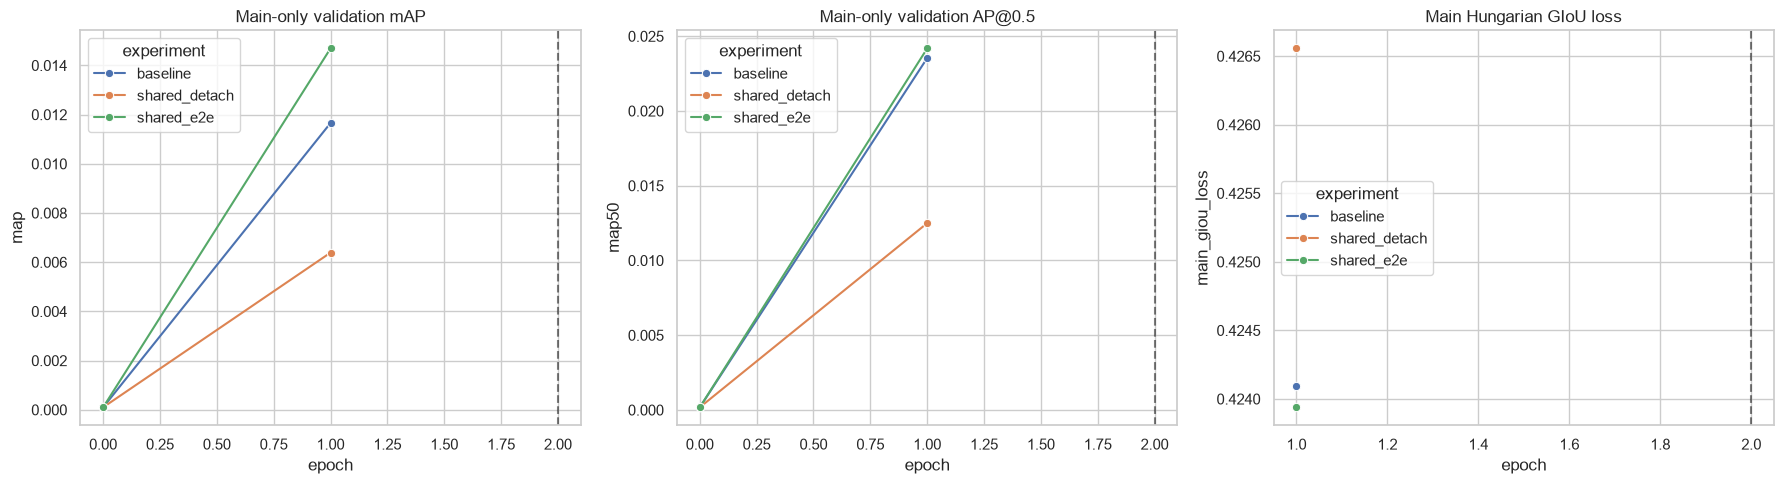

,map_mean,map_sd,map50_mean,map50_sd,map75_mean,train_seconds_mean,aux_coverage_mean,collision_rate_mean
experiment,,,,,,,,
shared_e2e,0.014691,NaN,0.024183,NaN,0.015691,7.825101,1.0,0.0
baseline,0.011658,NaN,0.023538,NaN,0.006895,8.297584,NaN,NaN
shared_detach,0.006388,NaN,0.012496,NaN,0.006824,7.763083,1.0,0.0


In [ ]:
if RUN_EXPERIMENTS and not history_df.empty:
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.lineplot(data=history_df, x='epoch', y='map', hue='experiment', marker='o', ax=axes[0])
    axes[0].set_title('Main-only validation mAP')
    sns.lineplot(data=history_df, x='epoch', y='map50', hue='experiment', marker='o', ax=axes[1])
    axes[1].set_title('Main-only validation AP@0.5')
    trained_rows = history_df[history_df['epoch'] > 0]
    sns.lineplot(data=trained_rows, x='epoch', y='main_giou_loss', hue='experiment', marker='o', ax=axes[2])
    axes[2].set_title('Main Hungarian GIoU loss')
    for axis in axes:
        axis.axvline(2, color='black', linestyle='--', alpha=0.5)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'main_convergence_{RUN_MODE}.png', dpi=160, bbox_inches='tight')
    plt.show()

    final_epoch = history_df['epoch'].max()
    final_rows = history_df[history_df['epoch'] == final_epoch]
    summary = final_rows.groupby('experiment').agg(
        map_mean=('map', 'mean'), map_sd=('map', 'std'),
        map50_mean=('map50', 'mean'), map50_sd=('map50', 'std'),
        map75_mean=('map75', 'mean'),
        train_seconds_mean=('train_seconds', 'mean'),
        aux_coverage_mean=('aux_coverage', 'mean'),
        collision_rate_mean=('collision_rate', 'mean'),
    ).sort_values('map50_mean', ascending=False)
    summary.to_csv(OUTPUT_DIR / f'summary_{RUN_MODE}.csv')
    display(summary)


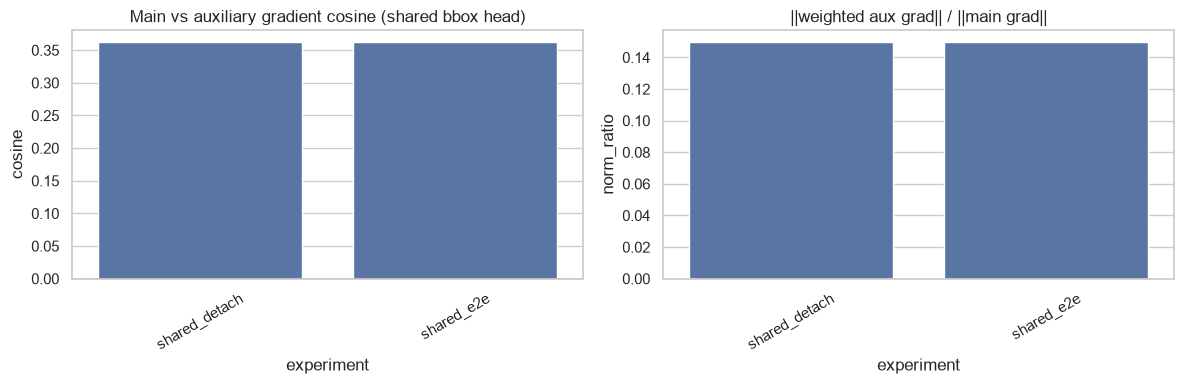

,experiment,seed,epoch,cosine,main_grad_norm,weighted_aux_grad_norm,norm_ratio
0,shared_detach,42,1,0.362118,21.562679,3.22531,0.149578
1,shared_e2e,42,1,0.362118,21.562679,3.22531,0.149578


In [ ]:
if RUN_EXPERIMENTS and not gradients_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=gradients_df, x='experiment', y='cosine', ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].set_title('Main vs auxiliary gradient cosine (shared bbox head)')
    sns.barplot(data=gradients_df, x='experiment', y='norm_ratio', ax=axes[1])
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].set_title('||weighted aux grad|| / ||main grad||')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'gradient_conflict_{RUN_MODE}.png', dpi=160, bbox_inches='tight')
    plt.show()
    display(gradients_df)


## 11. GT 없는 정성 결과

마지막으로 학습된 모델을 `labels=None`으로 실행한다. 표시되는 box는 auxiliary prediction이 아니라 300 object query 중 class score가 높은 main DETR prediction이다.


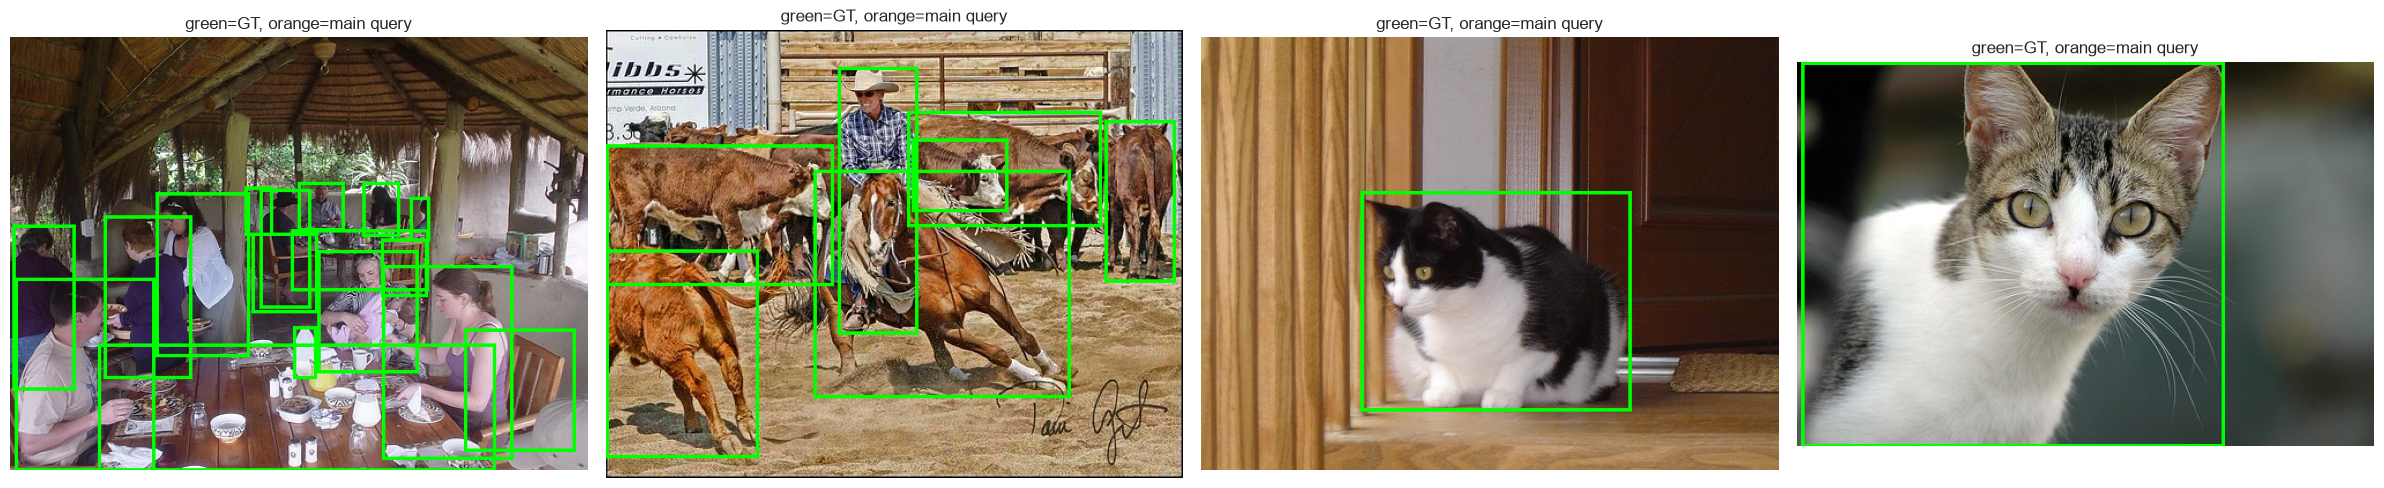

In [ ]:
@torch.inference_mode()
def visualize_main_predictions(model, records, count=4, threshold=0.4):
    if model is None:
        return
    model.eval()
    dataset = VOCDataset(records[:count], training=False)
    loader = DataLoader(
        dataset, batch_size=count, shuffle=False,
        num_workers=0, collate_fn=collate_detection_batch,
    )
    batch = next(iter(loader))
    calls_before = model.aux_forward_calls
    result = model(
        pixel_values=batch['pixel_values'].to(DEVICE),
        pixel_mask=batch['pixel_mask'].to(DEVICE),
        labels=None,
    )
    assert not result['aux_executed'] and model.aux_forward_calls == calls_before
    target_sizes = torch.stack([
        target['orig_size'] for target in batch['eval_targets']
    ]).to(DEVICE)
    predictions = processor.post_process_object_detection(
        result['outputs'], threshold=threshold, target_sizes=target_sizes
    )

    fig, axes = plt.subplots(1, count, figsize=(6 * count, 6))
    axes = np.atleast_1d(axes)
    for axis, record, prediction in zip(axes, records[:count], predictions):
        image = Image.open(record['image_path']).convert('RGB')
        draw = ImageDraw.Draw(image)
        for box in record['boxes_xyxy']:
            draw.rectangle(box, outline='lime', width=3)
        for score, label, box in zip(
            prediction['scores'].cpu(), prediction['labels'].cpu(), prediction['boxes'].cpu()
        ):
            coords = box.tolist()
            draw.rectangle(coords, outline='orange', width=2)
            draw.text((coords[0], coords[1]), f'{ID2LABEL[int(label)]} {float(score):.2f}', fill='orange')
        axis.imshow(image)
        axis.set_title('green=GT, orange=main query')
        axis.axis('off')
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'main_predictions_{RUN_MODE}.png', dpi=160, bbox_inches='tight')
    plt.show()

if RUN_EXPERIMENTS:
    visualize_main_predictions(last_model, val_records)


## 12. 결과 판정 규칙과 다음 단계

이 실험에서 GT-supervised auxiliary path가 유효하다고 판단하려면 다음 조건을 함께 만족해야 한다.

1. `shared_e2e` 또는 `shared_decay`의 **main-only** epoch 1/2/5 AP가 baseline보다 높다.
2. 최종 main-only AP가 유지되거나 개선된다.
3. `separate`보다 `shared`가 우수해 bbox predictor 직접 감독의 효과가 나타난다.
4. `random_patch`에서 효과가 감소해 GT patch alignment가 실제 원인임을 확인한다.
5. 3개 seed에서 개선 방향이 일관되고 confidence interval이 보고된다.

위험 신호와 대응:

- gradient cosine이 지속적으로 음수: `shared_decay` 또는 더 작은 auxiliary weight 사용
- weighted aux/main gradient norm ratio가 매우 큼: auxiliary weight 감소
- collision rate가 큼: 방법의 구조적 한계로 보고하고 해상도/선택 정책을 별도 ablation
- adapter와 decoder feature norm 차이가 큼: adapter warm-up 또는 feature normalization 검토
- auxiliary loss만 빠르게 감소하고 main AP가 그대로임: “쉬운 oracle task만 학습”된 것으로 결론
- AP 개선이 `separate`에서도 동일함: shared head보다 encoder dense supervision 효과일 가능성

Full 1-seed에서 경향이 확인된 뒤 `SEEDS=[42,43,44]`로 반복한다. 그 다음 단계에서만 iterative box refinement나 DINO/RT-DETR로 확장한다.


In [ ]:
if RUN_EXPERIMENTS and not history_df.empty:
    primary = 'shared_decay' if 'shared_decay' in history_df['experiment'].unique() else 'shared_e2e'
    baseline = history_df[history_df['experiment'] == 'baseline']
    proposed = history_df[history_df['experiment'] == primary]
    common_epochs = sorted(set(baseline['epoch']).intersection(proposed['epoch']))
    comparison_rows = []
    for epoch in common_epochs:
        base_row = baseline[baseline['epoch'] == epoch]
        prop_row = proposed[proposed['epoch'] == epoch]
        comparison_rows.append({
            'epoch': epoch,
            'baseline_map50': base_row['map50'].mean(),
            f'{primary}_map50': prop_row['map50'].mean(),
            'delta_map50': prop_row['map50'].mean() - base_row['map50'].mean(),
            'baseline_map': base_row['map'].mean(),
            f'{primary}_map': prop_row['map'].mean(),
            'delta_map': prop_row['map'].mean() - base_row['map'].mean(),
        })
    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(OUTPUT_DIR / f'baseline_vs_{primary}_{RUN_MODE}.csv', index=False)
    display(comparison_df)
    print('주의: smoke mode 결과는 구현 검증용이며 연구 결론으로 사용하지 않습니다.')


,epoch,baseline_map50,shared_e2e_map50,delta_map50,baseline_map,shared_e2e_map,delta_map
0,0,0.000177,0.000177,0.000000,0.000100,0.000100,0.000000
1,1,0.023538,0.024183,0.000645,0.011658,0.014691,0.003033


주의: smoke mode 결과는 구현 검증용이며 연구 결론으로 사용하지 않습니다.
